## Initalizing

In [6]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
class linear_regression_model:
    def __init__(self, learning_rate=1e-5, max_iterations=1000, tolerance= 1e-5, print_cost=True):
        self.learning_rate = learning_rate
        self.max_iterations = max_iterations
        self.tolerance = tolerance
        self.print_cost = print_cost

        self.X = None
        self.Y = None
        self.weights = None
        self.last_cost = None
        
    def hypothesis(self, X, weights):
        #TODO: cancel the reshape
        weights = weights.reshape((1, self.n_features))  # shape (2,1)
        return np.dot(X, weights.T)
    
    def cost(self, Yhat):
        return np.sum(np.power(self.Y - Yhat, 2))
    
    def cost_by_weights(self, weights):
        Yhat = self.hypothesis(self.X, weights)
        return self.cost(Yhat)
    
    def gradient(self, weights, delta=1e-5):
        # Ensure x is a numpy array for numerical operations
        weights = np.array(weights, dtype=float)
        # Initialize the gradient vector with zeros
        gradient = np.zeros_like(weights)
        
        # Iterate over each dimension (variable) of the input point x
        for i in range(len(weights)):
            # Create a small change vector for the current dimension
            weights_plus_delta = weights.copy()
            weights_minus_delta = weights.copy()
            
            weights_plus_delta[i] += delta
            weights_minus_delta[i] -= delta
            
            # Approximate the partial derivative using the central difference formula
            # (f(x + delta_i) - f(x - delta_i)) / (2 * delta)
            partial_derivative = (self.cost_by_weights(weights_plus_delta) - self.cost_by_weights(weights_minus_delta)) / (2 * delta)
            gradient[i] = partial_derivative
        
        return gradient

    def hessian(self, weights, epsilon=1e-5):
        x = np.array(weights, dtype=float)
        
        n = len(x)
        hessian = np.zeros((n, n))

        for i in range(n):
            x_plus_i = x.copy()
            x_minus_i = x.copy()
            x_plus_i[i] += epsilon
            x_minus_i[i] -= epsilon

            # Calculate the gradient at x + epsilon in the i-th direction
            grad_plus = self.gradient(x_plus_i)
            # Calculate the gradient at x - epsilon in the i-th direction
            grad_minus = self.gradient(x_minus_i)

            # Approximate the second derivative (the i-th row of the Hessian)
            # by taking the difference of the gradients and dividing by 2*epsilon
            hessian[i, :] = (grad_plus - grad_minus) / (2 * epsilon)

        return hessian
    
    def gradient_descent(self, X, Y, Yhat):
        self.weights = self.weights + self.learning_rate * np.dot((Y - Yhat).T, X)
        return self.weights
    
    def fit(self, X, Y):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        self.X = X
        self.Y = Y

        self.n_samples, self.n_features = X.shape
        
        self.weights = np.zeros((1, self.n_features))
        self.last_cost = 0
        
        for it in range(self.max_iterations):
            Yhat = self.hypothesis(X, self.weights)
            cost = self.cost(Yhat)
            
            if abs(cost - self.last_cost) <= self.tolerance:
                break
            self.last_cost = cost

            if self.print_cost:
                print(f"Cost at iteration {it} is {cost}")

            self.weights = self.gradient_descent(X, Y, Yhat)

        return self.weights
    
    def normal_equation(self, X, Y):
        self.X = X
        self.Y = Y
        
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        self.weights = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, Y)).T
        
        print("Cost by normal equation:", self.cost(self.hypothesis(X, self.weights)))
        return self.weights
    
    def newtons_method(self, X, Y):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        self.X = X
        self.Y = Y

        self.n_samples, self.n_features = X.shape
        self.weights = np.zeros((self.n_features,))

        for i in range(self.max_iterations):
            grad = self.gradient(self.weights)
            hess = self.hessian(self.weights)

            self.weights -= np.linalg.inv(hess).dot(grad)
            
            Yhat = self.hypothesis(X, self.weights)
            cost = self.cost(Yhat)
            if self.print_cost:
                print(f"Cost at iteration {i} is {cost}")

            if np.linalg.norm(grad) < self.tolerance:
                break

        return self.weights
    

    def predict(self, X):
        X = np.hstack([np.ones((X.shape[0], 1)), X])
        print(self.weights)

        return self.hypothesis(X, self.weights)


## Generate data

In [7]:
np.random.seed(42)

X = np.random.rand(50, 1) * 100  
X = np.vstack([np.array([[0]]), X])

Y = 3.5 * X + np.random.randn(51, 1) * 20 -200

print(X.shape, Y.shape)

(51, 1) (51, 1)


## Training

In [ ]:
# model = linear_regression_model(learning_rate=1e-5, max_iterations=50000, tolerance=1e-1)

# model.fit(X, Y)
# Y_pred_gd = model.predict(X)

# model = linear_regression_model(learning_rate=1e-5, max_iterations=50000)

# model.normal_equation(X, Y)
# Y_pred_ne = model.predict(X)

model = linear_regression_model(learning_rate=1e-5, max_iterations=50000)

model.newtons_method(X, Y)
Y_pred_nm = model.predict(X)

Cost at iteration 0 is 16271.908762183926
Cost at iteration 1 is 15922.202658342147
Cost at iteration 2 is 15922.20262767963
Cost at iteration 3 is 15922.202627679622
Cost at iteration 4 is 15922.20262767963
[-194.74011428    3.37923594]


## Plotting

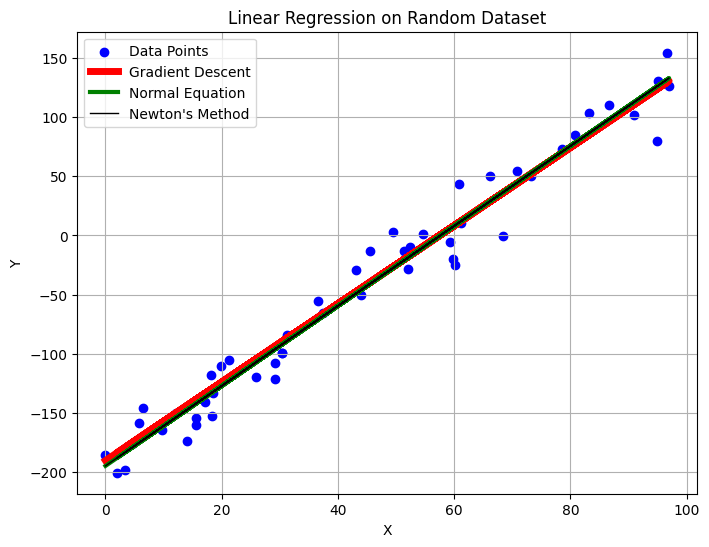

In [5]:
plt.figure(figsize=(8,6)) 
plt.scatter(X, Y, color='blue', label='Data Points') 
plt.plot(X, Y_pred_gd, color='red', linewidth=5, label='Gradient Descent') 
plt.plot(X, Y_pred_ne, color='green', linewidth=3, label='Normal Equation') 
plt.plot(X, Y_pred_nm, color='black', linewidth=1, label='Newton\'s Method') 
plt.title('Linear Regression on Random Dataset')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()